# ReAct (Reason + Act) Pattern — In Depth

## Table of Contents
1. [What Is It?](#what-is-it)
2. [Why Does It Matter?](#why-does-it-matter)
3. [How It Works — Architecture](#how-it-works--architecture)
4. [Comparison With Other Agentic Patterns](#comparison-with-other-agentic-patterns)
5. [Real-World Use Cases](#real-world-use-cases)
6. [Building It From Scratch (LangGraph Internal Logic)](#building-it-from-scratch-langgraph)
7. [Key Takeaways](#key-takeaways)

---

## What Is It?

The **ReAct (Reason + Act)** pattern is a foundational agentic architecture that forces a Large Language Model to interleave **Reasoning traces** (thinking about what to do) with **Actions** (using tools to interact with the external world). 

Originated in a landmark 2022 research paper (*"ReAct: Synergizing Reasoning and Acting in Language Models"* by Yao et al.), it solves a critical problem: LLMs that only "think" often hallucinate facts, and LLMs that only "act" often take actions blindly without a coherent strategy. ReAct combines both into a continuous, observable loop.

```mermaid
flowchart TD
    Start["User Request"] --> Reason
    
    subgraph ReAct Loop
        Reason["🧠 Reason (Thought)"]
        Action["🛠️ Act (Tool Call)"]
        Observe["👀 Observe (Tool Result)"]
        
        Reason -->|Needs external info| Action
        Action --> Observe
        Observe -->|"Update Context"| Reason
    end
    
    Reason -->|Has final answer| Final["Final Response"]
```

---

## Why Does It Matter?

Before ReAct, developers struggled to get LLMs to solve multi-step problems reliably. 

### The Problem With Standard LLMs
| Problem | Description |
|---------|-------------|
| **Hallucination** | If asked a factual question it doesn't know, a standard LLM will guess and lie confidently. |
| **Error Propagation** | If an LLM makes a mistake in step 1 of a complex problem, all subsequent steps fail. |
| **Blind Execution** | If given tools without a reasoning trace, an LLM might just call random tools hoping to get the right data. |

### What ReAct Solves
| Benefit | How |
|---------|-----|
| **Grounding in Reality** | By forcing the LLM to *Act* (e.g., search the web) and *Observe*, it bases its final answer on real, retrieved data rather than its own weights. |
| **Self-Correction** | If a tool fails or returns empty data, the *Reasoning* phase allows the LLM to recognize the failure and try a different tool or search query. |
| **Interpretability** | Because the LLM outputs a "Thought" before every action, human developers can read the logs and see *exactly* why the AI made a specific decision. |

---

## How It Works — Architecture

The ReAct pattern operates on a continuous while-loop. The prompt given to the LLM is usually structured to force the following output format:

1. **Thought**: The LLM explains its current understanding and what it needs to do next.
2. **Action**: The LLM specifies a tool to use and the inputs for that tool.
3. **Observation**: The system (outside the LLM) executes the tool and appends the raw result back to the prompt.

*...this loop repeats until the Thought phase determines it has enough information to provide the final answer.*

### The Core Loop in LangGraph

In LangGraph, ReAct is implemented as a simple, cyclical `StateGraph` with two main nodes:
1. **Agent Node (Reasoner)**: Calls the LLM. If the LLM returns standard text, the loop ends. If the LLM returns a `tool_call`, the graph routes to the Tool Node.
2. **Tool Node (Executor)**: Executes the requested python function, packages the result as a `ToolMessage`, and routes *back* to the Agent Node to observe the results.

---

## Comparison With Other Agentic Patterns

| Dimension | ReAct | Plan-and-Execute | Standard Tool Calling |
|-----------|-------|------------------|-----------------------|
| **Planning Style** | Just-in-time / Step-by-step | Upfront / Comprehensive | None (usually one-shot) |
| **Adaptability** | High (Can pivot instantly if a tool fails) | Medium (Requires a "replanner" to pivot) | Low |
| **Latency/Speed** | Slower (requires an LLM call for every single step) | Moderate (One big plan, then rapid execution) | Fast |
| **Complexity Limit**| Starts to lose track after ~7-10 steps | Can handle 10-20+ steps easily | 1-2 steps |

> [!TIP]
> **When to use ReAct**: ReAct is the perfect default for almost any basic agent. Use it for research bots, customer support, or data retrieval. 
> **When NOT to use ReAct**: If your task requires 15+ highly dependent steps (like writing a whole software application), the ReAct loop will get confused. Use **Plan-and-Execute** instead.

---

## Real-World Use Cases

### 1. Customer Support AI
- **Thought**: "The user is asking about the status of order #12345. I need to check the database."
- **Action**: `query_database(order_id="12345")`
- **Observation**: `{status: "Shipped", tracking: "FedEx..."}`
- **Thought**: "I see it shipped. I will inform the user."

### 2. Financial Data Analyst
- **Thought**: "User wants the P/E ratio of Apple vs Microsoft. I'll get Apple first."
- **Action**: `get_stock_data(ticker="AAPL")`
- **Observation**: `[Financial Data...]`
- **Thought**: "Now I need Microsoft."
- **Action**: `get_stock_data(ticker="MSFT")`

### 3. Debugging / Coding Assistant
- **Thought**: "The python script threw an IndexError. I should read the file lines 10-20 to see the array."
- **Action**: `read_file(path="script.py", lines="10-20")`
- **Observation**: `[Code snippet]`
- **Thought**: "Ah, the loop is off-by-one. I will propose a fix."

---

## Key Takeaways

> [!IMPORTANT]
> ### Summary of the ReAct Pattern
> 
> 1. **What**: A cyclical pattern interleaving LLM Reasoning and Tool Execution (Observation).
> 2. **Why**: Grounds the LLM in reality, prevents hallucination, and allows for multi-step error correction.
> 3. **How**: Implemented via a `StateGraph` that loops between an Agent Node and a Tool Node, driven by conditional edges checking for the presence of `tool_calls`.
> 4. **When**: The default architecture for almost all modern single-agent systems handling dynamic tasks.

### Behind the Scenes
- The LLM does not inherently "know" how to execute code. It only outputs a JSON string requesting a tool.
- The framework (LangGraph) intercepts that JSON, runs your local python code, and formats the result as a `ToolMessage`.
- Without the `ToolMessage` routing back to the LLM, the LLM would never see the observation! The loop is what makes ReAct work.

## Complete Implementation Code

In [ ]:
"""
ReAct (Reason + Act) Pattern — LangGraph Implementation
=====================================================

This script implements the internal logic of the ReAct pattern from scratch.
Instead of using the prebuilt `create_react_agent`, we manually build the 
StateGraph to demonstrate the loop between reasoning and acting.

Architecture:
    START -> Reasoner (LLM) <---> Executor (Tools)
                 |
                 v
                END
"""




## Building It From Scratch (LangGraph)

While LangGraph provides a handy `create_react_agent` prebuilt function, **we are going to build the internal logic from scratch**. This is crucial to understanding exactly how ReAct works under the hood.

We will build a simple **Weather & Math Agent**.

In [2]:
import os
from dotenv import load_dotenv

# LangGraph and LangChain imports
from langgraph.graph import StateGraph, START, END, MessagesState
# from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.tools import tool
from langchain_groq import ChatGroq

In [3]:
load_dotenv()

True

In [4]:
# ==============================================================================
# Step 1: Define Tools
# ==============================================================================

@tool
def get_weather(location: str) -> str:
    """Get the current weather for a location."""
    if location.lower() == "london":
        return "It is currently 15°C and raining in London."
    elif location.lower() == "tokyo":
        return "It is currently 22°C and sunny in Tokyo."
    return f"It is mild and 20°C in {location}."

@tool
def calculate(expression: str) -> str:
    """Evaluate a mathematical expression. Use for math problems."""
    try:
        # Note: eval is used here strictly for the tutorial mock environment.
        # NEVER use raw eval() in production code.
        return str(eval(expression))
    except Exception as e:
        return f"Error calculating: {e}"

tools = [get_weather, calculate]
tool_mapping = {tool.name: tool for tool in tools}

# Setup Model and Bind Tools

model = ChatGroq(
    model="llama-3.3-70b-versatile"
)# Load environment variables (e.g., OPENAI_API_KEY)
model_with_tools = model.bind_tools(tools)


In [5]:


# ==============================================================================
# Step 2: The Reasoner Node (Thought/Action Generation)
# ==============================================================================

def reasoner_node(state: MessagesState):
    print("\n🧠 [REASONER]: Thinking...")
    
    # The LLM reads the history and responds
    response = model_with_tools.invoke(state["messages"])
    
    # If the LLM makes a tool call, we can print its "Thought" process
    if response.tool_calls:
        for tc in response.tool_calls:
            print(f"   -> Thought: I need to use '{tc['name']}' with args: {tc['args']}")
    else:
        print("   -> Thought: I have enough information to answer.")
        
    # We append the LLM's response to the state
    return {"messages": [response]}



In [6]:

# ==============================================================================
# Step 3: The Executor Node (Observation Generation)
# ==============================================================================

def executor_node(state: MessagesState):
    print("\n🛠️ [EXECUTOR]: Executing tools...")
    
    # The last message in the state is the AI's tool call
    last_message = state["messages"][-1]
    
    # We must return a list of ToolMessages containing the observations
    tool_messages = []
    
    for tool_call in last_message.tool_calls:
        # Find the actual python function
        tool_function = tool_mapping[tool_call["name"]]
        
        # Execute the function
        print(f"   -> Running {tool_call['name']}...")
        observation = tool_function.invoke(tool_call["args"])
        print(f"   -> Observation: {observation}")
        
        # Create the ToolMessage (this acts as the 'Observation' sent back to LLM)
        tool_messages.append(
            ToolMessage(
                content=str(observation),
                tool_call_id=tool_call["id"],
                name=tool_call["name"]
            )
        )
        
    # Appending the tool messages back to the state
    return {"messages": tool_messages}



In [7]:

# ==============================================================================
# Step 4: The Conditional Router
# ==============================================================================

def should_continue(state: MessagesState) -> str:
    last_message = state["messages"][-1]
    
    # If there are tool calls, we must execute them
    if getattr(last_message, "tool_calls", None):
        return "continue"
    # Otherwise, we are done
    return "end"



In [8]:

# ==============================================================================
# Step 5: Compile the Graph
# ==============================================================================

workflow = StateGraph(MessagesState)

# Add Nodes
workflow.add_node("reasoner", reasoner_node)
workflow.add_node("executor", executor_node)

# Add Edges
workflow.add_edge(START, "reasoner")

# The conditional edge decides if we loop or stop
workflow.add_conditional_edges(
    "reasoner",
    should_continue,
    {
        "continue": "executor",
        "end": END
    }
)

# After tools execute, ALWAYS go back to the reasoner to observe!
workflow.add_edge("executor", "reasoner")

react_graph = workflow.compile()



In [9]:

# ==============================================================================
# Step 6: Run It
# ==============================================================================

if __name__ == "__main__":
    print("\n" + "=" * 60)
    print("🔄 REACT PATTERN — Internal Logic Demo")
    print("=" * 60)

    # We ask a multi-step question that forces the ReAct loop to cycle multiple times
    request = "What is the weather in London? Also, what is 45 * 12?"
    print(f"User Request: {request}\n")

    # Run the workflow
    result = react_graph.invoke({"messages": [HumanMessage(content=request)]})

    print("\n" + "=" * 60)
    print("🎯 FINAL OUTPUT TO USER")
    print("=" * 60)
    
    # The last message is the final answer from the Reasoner
    print(result["messages"][-1].content)
    print("\nDone.")


🔄 REACT PATTERN — Internal Logic Demo
User Request: What is the weather in London? Also, what is 45 * 12?


🧠 [REASONER]: Thinking...
   -> Thought: I need to use 'get_weather' with args: {'location': 'London'}
   -> Thought: I need to use 'calculate' with args: {'expression': '45 * 12'}

🛠️ [EXECUTOR]: Executing tools...
   -> Running get_weather...
   -> Observation: It is currently 15°C and raining in London.
   -> Running calculate...
   -> Observation: 540

🧠 [REASONER]: Thinking...
   -> Thought: I have enough information to answer.

🎯 FINAL OUTPUT TO USER
The current weather in London is 15°C and raining. The result of the mathematical expression 45 * 12 is 540.

Done.


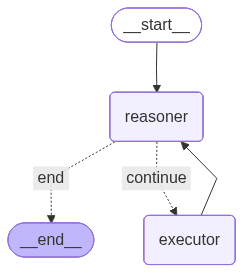

In [10]:
react_graph 